# Origin Classification with TF-IDF

Baseline pipeline for country-level origin classification using tasting text.

In [12]:
import re
import string
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, f1_score, balanced_accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from nltk.stem import PorterStemmer, WordNetLemmatizer
import matplotlib.pyplot as plt


In [13]:
DATA_PATH = 'Data/final_coffee_reviews.csv'
RANDOM_STATE = 42
MIN_SAMPLES_PER_CLASS = 30

df = pd.read_csv(DATA_PATH)
print('Shape:', df.shape)
df.head(2)

Shape: (7585, 25)


,URL,all_text,Rating,Roaster,Coffee Name,Roaster Location,Coffee Origin,Roast Level,Agtron,Est. Price,...,Flavor,Aftertaste,With Milk,Blind Assessment,Notes,Who Should Drink It,Bottom Line,Combined_Acidity,Country_all,Country
0,https://www.coffeereview.com/review/100-arabic...,87\nCaribeans\n100% Arabica Coffee from Puerto...,87.0,Caribeans,100% Arabica Coffee from Puerto Rico,"San Juan, Puerto Rico","Utuado, central Puerto Rico",Medium-Light,54/69,$17.00/8 ounces,...,8.0,7.0,NaN,bittersweet but balanced; chocolaty. dark choc...,Produced on a single farm in the central mount...,NaN,Satisfying chocolate and nut notes nearly carr...,7.0,Puerto Rico; China,Puerto Rico
1,https://www.coffeereview.com/review/100-arabic...,88\nWaka Coffee\n100% Arabica Freeze-Dried Col...,88.0,Waka Coffee,100% Arabica Freeze-Dried Colombian (Instant C...,"Los Angeles, California",Colombia,NaN,0/0,$10.99/8 single-serve packets,...,8.0,8.0,NaN,evaluated at proportions of 5 grams of instant...,The green coffee for this product was produced...,NaN,A appealing 100% Colombia coffee in instant fo...,7.0,Colombia,Colombia


In [14]:
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

coffee_terms_to_keep = {
    'acid', 'acidity', 'aromatic', 'berry', 'bright', 'buttery', 'caramel', 'cherry',
    'chocolate', 'citrus', 'clean', 'cocoa', 'creamy', 'crisp', 'dark', 'drying',
    'earthy', 'finish', 'flavor', 'floral', 'flower', 'fruit', 'fruity', 'honey',
    'jasmine', 'juicy', 'lemon', 'lime', 'mouthfeel', 'nectarine', 'nut', 'nutty',
    'orange', 'peach', 'rose', 'round', 'silky', 'smooth', 'spice', 'spicy', 'stone',
    'sweet', 'syrupy', 'tangerine', 'tea', 'tone', 'vanilla', 'winey'
}
stop_words = set(ENGLISH_STOP_WORDS) - coffee_terms_to_keep

misspelling_replacements = {
    r'\bchocolaty\b': 'chocolate',
    r'\bchoclate\b': 'chocolate',
    r'\bcitrussy\b': 'citrus',
    r'\bcitricy\b': 'citrus',
    r'\bcaramelly\b': 'caramel',
    r'\bcarmel\b': 'caramel',
    r'\bflorals\b': 'floral',
    r'\bfruity\b': 'fruit',
    r'\bnutty\b': 'nut',
    r'\bberries\b': 'berry',
}

phrase_replacements = {
    r'\bdark\s+chocolate\b': 'dark_chocolate',
    r'\bmilk\s+chocolate\b': 'milk_chocolate',
    r'\bbaking\s+chocolate\b': 'baking_chocolate',
    r'\bstone\s+fruit\b': 'stone_fruit',
    r'\borange\s+zest\b': 'orange_zest',
    r'\blemon\s+zest\b': 'lemon_zest',
    r'\bbrown\s+sugar\b': 'brown_sugar',
    r'\bred\s+apple\b': 'red_apple',
    r'\bpipe\s+tobacco\b': 'pipe_tobacco',
    r'\baromatic\s+wood\b': 'aromatic_wood',
    r'\btea\s+rose\b': 'tea_rose',
    r'\bdried\s+berry\b': 'dried_berry',
    r'\bchocolatey\b': 'chocolate',
    r'\bcocoa\s+toned\b': 'cocoa',
    r'\bcitrusy\b': 'citrus',
    r'\bberry\s+like\b': 'berry',
    r'\bberrylike\b': 'berry',
    r'\bfruit\s+toned\b': 'fruit',
    r'\bfloral\s+toned\b': 'floral',
    r'\bnut\s+toned\b': 'nut',
    r'\bcaramel\s+like\b': 'caramel',
    r'\bsweet\s+toned\b': 'sweet',
}


def minimal_raw_text(text: str) -> str:
    if not isinstance(text, str):
        return ''
    text = text.strip()
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text


def apply_replacements(text: str) -> str:
    for pattern, replacement in misspelling_replacements.items():
        text = re.sub(pattern, replacement, text)
    for pattern, replacement in phrase_replacements.items():
        text = re.sub(pattern, replacement, text)
    return text


def normalize_text(text: str) -> str:
    text = minimal_raw_text(text).lower()
    text = apply_replacements(text)
    text = re.sub(r'[^a-z_\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()


def remove_domain_stopwords(text: str) -> str:
    tokens = [token for token in text.split() if token not in stop_words]
    return ' '.join(tokens)


def remove_domain_stopwords_and_stem(text: str) -> str:
    tokens = [stemmer.stem(token) for token in text.split() if token not in stop_words]
    return ' '.join(tokens)


def remove_domain_stopwords_and_lemmatize(text: str) -> str:
    tokens = [lemmatizer.lemmatize(token) for token in text.split() if token not in stop_words]
    return ' '.join(tokens)


In [15]:
# Build text input variants for preprocessing ablation
df['text_raw_minimal'] = df['Blind Assessment'].fillna('').map(minimal_raw_text)
df['text_basic'] = df['Blind Assessment'].fillna('').map(normalize_text)
df['text_domain_stopwords'] = df['text_basic'].map(remove_domain_stopwords)
df['text_domain_stopwords_stemmed'] = df['text_basic'].map(remove_domain_stopwords_and_stem)
df['text_domain_stopwords_lemmatized'] = df['text_basic'].map(remove_domain_stopwords_and_lemmatize)
df['text_main'] = df['text_basic']

# Use the country label prepared in notebook 01
df['origin_country'] = df['Country'].astype('string').str.strip()
df['origin_country'] = df['origin_country'].replace('', pd.NA)

# Keep valid rows only
work = df[(df['text_raw_minimal'].str.len() >= 30) & (df['origin_country'].notna())].copy()

# Remove tiny classes for a stable baseline
counts = work['origin_country'].value_counts()
valid_classes = counts[counts >= MIN_SAMPLES_PER_CLASS].index
work = work[work['origin_country'].isin(valid_classes)].copy()

print('Rows after filtering:', len(work))
print('Num classes:', work['origin_country'].nunique())
work['origin_country'].value_counts().head(15)


Rows after filtering: 7437
Num classes: 25


origin_country
Ethiopia         1996
Colombia          988
Kenya             699
Guatemala         561
Indonesia         452
Costa Rica        373
Panama            354
United States     302
El Salvador       240
Brazil            200
Rwanda            176
Peru              130
Nicaragua         125
Honduras          123
Mexico            101
Name: count, dtype: Int64

In [16]:
dataset_summary = pd.DataFrame({
    'metric': [
        'Rows in raw dataset',
        'Rows after preprocessing/filtering',
        'Unique origin classes after filtering',
        'Minimum samples per class',
        'Review date min',
        'Review date max',
    ],
    'value': [
        len(df),
        len(work),
        work['origin_country'].nunique(),
        MIN_SAMPLES_PER_CLASS,
        df['Review Date'].min(),
        df['Review Date'].max(),
    ]
})

dataset_summary


,metric,value
0,Rows in raw dataset,7585
1,Rows after preprocessing/filtering,7437
2,Unique origin classes after filtering,25
3,Minimum samples per class,30
4,Review date min,1997-02-01
5,Review date max,2026-03-01


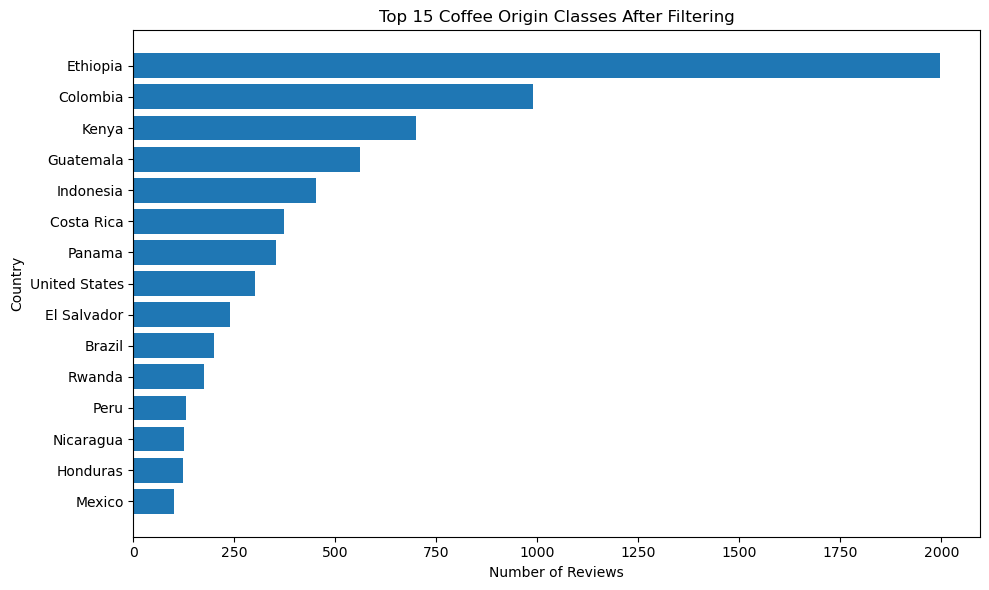

In [17]:
origin_counts = work['origin_country'].value_counts().head(15).sort_values()

plt.figure(figsize=(10, 6))
plt.barh(origin_counts.index, origin_counts.values)
plt.xlabel('Number of Reviews')
plt.ylabel('Country')
plt.title('Top 15 Coffee Origin Classes After Filtering')
plt.tight_layout()
plt.show()


In [18]:
work = work.reset_index(drop=True)
y = work['origin_country']
row_idx = work.index

# 70/15/15 split (stratified)
train_idx, temp_idx, y_train, y_temp = train_test_split(
    row_idx, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)
val_idx, test_idx, y_val, y_test = train_test_split(
    temp_idx, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
)

print('Train:', len(train_idx), 'Val:', len(val_idx), 'Test:', len(test_idx))

Train: 5205 Val: 1116 Test: 1116


In [19]:
def evaluate(model, X_data, y_true, split_name='split'):
    y_pred = model.predict(X_data)
    acc = accuracy_score(y_true, y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)

    print(f'== {split_name} ==')
    print(f'Accuracy:  {acc:.4f}')
    print(f'Balanced Accuracy: {bal_acc:.4f}')
    print(f'Precision: {p:.4f}')
    print(f'Recall:    {r:.4f}')
    print(f'F1-macro:  {f1:.4f}')

    return y_pred


In [20]:
preprocessing_variants = {
    'Raw text / punctuation preserved': 'text_raw_minimal',
    'Basic normalization': 'text_basic',
    'Domain stopword removal': 'text_domain_stopwords',
    'Domain stopword removal + stemming': 'text_domain_stopwords_stemmed',
    'Domain stopword removal + lemmatization': 'text_domain_stopwords_lemmatized',
}

ablation_results = []
best_preprocessing_name = None
best_text_column = None
best_preprocessing_val_f1 = -1

for variant_name, column_name in preprocessing_variants.items():
    X_train_variant = work.loc[train_idx, column_name]
    X_val_variant = work.loc[val_idx, column_name]
    X_test_variant = work.loc[test_idx, column_name]

    ablation_model = Pipeline([
        ('tfidf', TfidfVectorizer(
            analyzer='word',
            ngram_range=(1, 2),
            min_df=3,
            max_df=0.90,
            sublinear_tf=True,
        )),
        ('clf', LinearSVC(
            C=1.0,
            class_weight='balanced',
            dual='auto',
            max_iter=10000,
            random_state=RANDOM_STATE,
        )),
    ])

    ablation_model.fit(X_train_variant, y_train)
    y_val_pred_variant = ablation_model.predict(X_val_variant)
    y_test_pred_variant = ablation_model.predict(X_test_variant)

    val_acc = accuracy_score(y_val, y_val_pred_variant)
    val_bal_acc = balanced_accuracy_score(y_val, y_val_pred_variant)
    val_p, val_r, val_f1, _ = precision_recall_fscore_support(y_val, y_val_pred_variant, average='macro', zero_division=0)
    test_acc = accuracy_score(y_test, y_test_pred_variant)
    test_bal_acc = balanced_accuracy_score(y_test, y_test_pred_variant)
    test_p, test_r, test_f1, _ = precision_recall_fscore_support(y_test, y_test_pred_variant, average='macro', zero_division=0)

    ablation_results.append({
        'preprocessing_variant': variant_name,
        'text_column': column_name,
        'val_accuracy': val_acc,
        'val_balanced_accuracy': val_bal_acc,
        'val_precision_macro': val_p,
        'val_recall_macro': val_r,
        'val_f1_macro': val_f1,
        'test_accuracy': test_acc,
        'test_balanced_accuracy': test_bal_acc,
        'test_precision_macro': test_p,
        'test_recall_macro': test_r,
        'test_f1_macro': test_f1,
    })

    if val_f1 > best_preprocessing_val_f1:
        best_preprocessing_val_f1 = val_f1
        best_preprocessing_name = variant_name
        best_text_column = column_name

ablation_results_df = pd.DataFrame(ablation_results).sort_values('val_f1_macro', ascending=False).reset_index(drop=True)
print('Selected preprocessing variant:', best_preprocessing_name)
print('Selected text column:', best_text_column)
ablation_results_df


Selected preprocessing variant: Raw text / punctuation preserved
Selected text column: text_raw_minimal


,preprocessing_variant,text_column,val_accuracy,val_balanced_accuracy,val_precision_macro,val_recall_macro,val_f1_macro,test_accuracy,test_balanced_accuracy,test_precision_macro,test_recall_macro,test_f1_macro
0,Raw text / punctuation preserved,text_raw_minimal,0.254480,0.138009,0.122198,0.138009,0.126110,0.266129,0.147441,0.141432,0.147441,0.140547
1,Basic normalization,text_basic,0.249104,0.133788,0.120614,0.133788,0.123625,0.261649,0.149699,0.143825,0.149699,0.143239
2,Domain stopword removal + stemming,text_domain_stopwords_stemmed,0.249104,0.128528,0.115726,0.128528,0.118854,0.250000,0.149827,0.127813,0.149827,0.134322
3,Domain stopword removal,text_domain_stopwords,0.247312,0.127746,0.117028,0.127746,0.118617,0.254480,0.147722,0.133974,0.147722,0.136839
4,Domain stopword removal + lemmatization,text_domain_stopwords_lemmatized,0.247312,0.125348,0.115167,0.125348,0.117410,0.253584,0.146788,0.135722,0.146788,0.137241


In [21]:
X_train = work.loc[train_idx, best_text_column]
X_val = work.loc[val_idx, best_text_column]
X_test = work.loc[test_idx, best_text_column]

# Reduced search space so tuning finishes in a reasonable time on local hardware
search_space = [
    {
        'model_name': ['Logistic Regression'],
        'analyzer': ['word'],
        'ngram_range': [(1, 1), (1, 2)],
        'min_df': [2, 5],
        'max_df': [0.90],
        'sublinear_tf': [True],
        'C': [1, 5],
    },
    {
        'model_name': ['Linear SVM'],
        'analyzer': ['word'],
        'ngram_range': [(1, 1), (1, 2)],
        'min_df': [2, 5],
        'max_df': [0.90],
        'sublinear_tf': [True],
        'C': [1, 5],
    },
    {
        'model_name': ['Logistic Regression'],
        'analyzer': ['char_wb'],
        'ngram_range': [(3, 5)],
        'min_df': [2, 5],
        'max_df': [0.90],
        'sublinear_tf': [True],
        'C': [1, 5],
    },
    {
        'model_name': ['Linear SVM'],
        'analyzer': ['char_wb'],
        'ngram_range': [(3, 5)],
        'min_df': [2, 5],
        'max_df': [0.90],
        'sublinear_tf': [True],
        'C': [1, 5],
    },
]

search_results = []
best_model = None
best_params = None
best_val_f1 = -1
print('Total tuned configurations:', sum(len(list(ParameterGrid(grid))) for grid in search_space))

for grid in search_space:
    for params in ParameterGrid(grid):
        vectorizer = TfidfVectorizer(
            analyzer=params['analyzer'],
            ngram_range=params['ngram_range'],
            min_df=params['min_df'],
            max_df=params['max_df'],
            sublinear_tf=params['sublinear_tf'],
        )

        if params['model_name'] == 'Logistic Regression':
            clf = LogisticRegression(
                C=params['C'],
                max_iter=5000,
                solver='liblinear',
                class_weight='balanced',
                multi_class='ovr',
                random_state=RANDOM_STATE,
            )
        else:
            clf = LinearSVC(
                C=params['C'],
                class_weight='balanced',
                dual='auto',
                max_iter=10000,
                random_state=RANDOM_STATE,
            )

        model = Pipeline([
            ('tfidf', vectorizer),
            ('clf', clf),
        ])

        model.fit(X_train, y_train)
        y_val_pred = model.predict(X_val)
        val_f1 = f1_score(y_val, y_val_pred, average='macro', zero_division=0)

        row = dict(params)
        row['val_f1_macro'] = val_f1
        search_results.append(row)

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_params = dict(params)
            best_model = model

search_results_df = pd.DataFrame(search_results).sort_values('val_f1_macro', ascending=False).reset_index(drop=True)
search_results_df.head(10)


Total tuned configurations: 24


,C,analyzer,max_df,min_df,model_name,ngram_range,sublinear_tf,val_f1_macro
0,5,char_wb,0.9,2,Logistic Regression,"(3, 5)",True,0.131204
1,1,word,0.9,2,Logistic Regression,"(1, 1)",True,0.126958
2,1,char_wb,0.9,2,Logistic Regression,"(3, 5)",True,0.125328
3,5,char_wb,0.9,5,Logistic Regression,"(3, 5)",True,0.124784
4,1,char_wb,0.9,2,Linear SVM,"(3, 5)",True,0.122794
5,1,char_wb,0.9,5,Logistic Regression,"(3, 5)",True,0.122320
6,5,word,0.9,2,Logistic Regression,"(1, 2)",True,0.121980
7,1,word,0.9,5,Logistic Regression,"(1, 1)",True,0.121395
8,1,char_wb,0.9,5,Linear SVM,"(3, 5)",True,0.121130
9,1,word,0.9,2,Logistic Regression,"(1, 2)",True,0.120973


In [22]:
print('Best validation F1-macro:', round(best_val_f1, 4))
best_params


Best validation F1-macro: 0.1312


{'C': 5,
 'analyzer': 'char_wb',
 'max_df': 0.9,
 'min_df': 2,
 'model_name': 'Logistic Regression',
 'ngram_range': (3, 5),
 'sublinear_tf': True}

In [23]:
_ = evaluate(best_model, X_val, y_val, 'Validation (Best Tuned TF-IDF Model)')
y_test_pred_best = evaluate(best_model, X_test, y_test, 'Test (Best Tuned TF-IDF Model)')

print('\nTop classes report (test, best tuned model):')
top_labels = y_test.value_counts().head(15).index
print(classification_report(y_test, y_test_pred_best, labels=top_labels, zero_division=0))


== Validation (Best Tuned TF-IDF Model) ==
Accuracy:  0.2590
Balanced Accuracy: 0.1425
Precision: 0.1335
Recall:    0.1425
F1-macro:  0.1312
== Test (Best Tuned TF-IDF Model) ==
Accuracy:  0.2599
Balanced Accuracy: 0.1619
Precision: 0.1402
Recall:    0.1619
F1-macro:  0.1442

Top classes report (test, best tuned model):
               precision    recall  f1-score   support

     Ethiopia       0.53      0.36      0.43       300
     Colombia       0.33      0.14      0.20       148
        Kenya       0.53      0.50      0.52       105
    Guatemala       0.20      0.15      0.18        84
    Indonesia       0.40      0.57      0.47        68
   Costa Rica       0.09      0.07      0.08        56
       Panama       0.14      0.21      0.17        53
United States       0.10      0.13      0.11        45
  El Salvador       0.15      0.19      0.17        36
       Brazil       0.16      0.27      0.20        30
       Rwanda       0.11      0.19      0.14        27
         Peru    

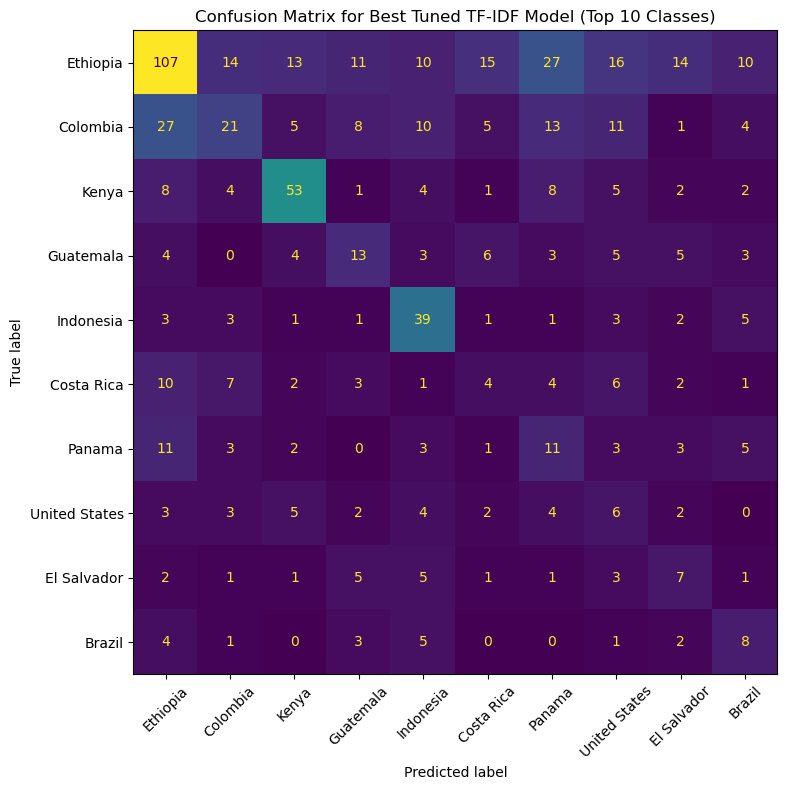

In [24]:
top_confusion_labels = y_test.value_counts().head(10).index
cm = confusion_matrix(y_test, y_test_pred_best, labels=top_confusion_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=top_confusion_labels)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title('Confusion Matrix for Best Tuned TF-IDF Model (Top 10 Classes)')
plt.tight_layout()
plt.show()


In [25]:
def build_model_from_params(params):
    vectorizer = TfidfVectorizer(
        analyzer=params['analyzer'],
        ngram_range=params['ngram_range'],
        min_df=params['min_df'],
        max_df=params['max_df'],
        sublinear_tf=params['sublinear_tf'],
    )

    if params['model_name'] == 'Logistic Regression':
        clf = LogisticRegression(
            C=params['C'],
            max_iter=5000,
            solver='liblinear',
            class_weight='balanced',
            multi_class='ovr',
            random_state=RANDOM_STATE,
        )
    else:
        clf = LinearSVC(
            C=params['C'],
            class_weight='balanced',
            dual='auto',
            max_iter=10000,
            random_state=RANDOM_STATE,
        )

    return Pipeline([
        ('tfidf', vectorizer),
        ('clf', clf),
    ])

def metric_row_explicit(label, y_val_true, y_val_pred, y_test_true, y_test_pred):
    val_acc = accuracy_score(y_val_true, y_val_pred)
    val_bal_acc = balanced_accuracy_score(y_val_true, y_val_pred)
    val_p, val_r, val_f1, _ = precision_recall_fscore_support(y_val_true, y_val_pred, average='macro', zero_division=0)
    test_acc = accuracy_score(y_test_true, y_test_pred)
    test_bal_acc = balanced_accuracy_score(y_test_true, y_test_pred)
    test_p, test_r, test_f1, _ = precision_recall_fscore_support(y_test_true, y_test_pred, average='macro', zero_division=0)

    return {
        'experiment': label,
        'val_accuracy': val_acc,
        'val_balanced_accuracy': val_bal_acc,
        'val_precision_macro': val_p,
        'val_recall_macro': val_r,
        'val_f1_macro': val_f1,
        'test_accuracy': test_acc,
        'test_balanced_accuracy': test_bal_acc,
        'test_precision_macro': test_p,
        'test_recall_macro': test_r,
        'test_f1_macro': test_f1,
    }


In [26]:
# Resampling is applied only on the training split to avoid leakage
train_df = pd.DataFrame({
    'text': X_train.reset_index(drop=True),
    'label': y_train.reset_index(drop=True),
})

max_train_count = train_df['label'].value_counts().max()
min_train_count = train_df['label'].value_counts().min()

oversampled_parts = []
undersampled_parts = []
for label, group in train_df.groupby('label'):
    oversampled_parts.append(group.sample(n=max_train_count, replace=True, random_state=RANDOM_STATE))
    undersampled_parts.append(group.sample(n=min_train_count, replace=False, random_state=RANDOM_STATE))

train_over = pd.concat(oversampled_parts, ignore_index=True).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
train_under = pd.concat(undersampled_parts, ignore_index=True).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print('Original training rows:', len(train_df))
print('Oversampled training rows:', len(train_over))
print('Undersampled training rows:', len(train_under))


Original training rows: 5205
Oversampled training rows: 34925
Undersampled training rows: 600


In [27]:
best_model_train_original = build_model_from_params(best_params)
best_model_train_original.fit(X_train, y_train)
y_val_pred_original = best_model_train_original.predict(X_val)
y_test_pred_original = best_model_train_original.predict(X_test)

best_model_train_over = build_model_from_params(best_params)
best_model_train_over.fit(train_over['text'], train_over['label'])
y_val_pred_over = best_model_train_over.predict(X_val)
y_test_pred_over = best_model_train_over.predict(X_test)

best_model_train_under = build_model_from_params(best_params)
best_model_train_under.fit(train_under['text'], train_under['label'])
y_val_pred_under = best_model_train_under.predict(X_val)
y_test_pred_under = best_model_train_under.predict(X_test)


In [28]:
resampling_results_df = pd.DataFrame([
    metric_row_explicit('Class weighting only', y_val, y_val_pred_original, y_test, y_test_pred_original),
    metric_row_explicit('Class weighting + oversampled training set', y_val, y_val_pred_over, y_test, y_test_pred_over),
    metric_row_explicit('Class weighting + undersampled training set', y_val, y_val_pred_under, y_test, y_test_pred_under),
]).sort_values('test_f1_macro', ascending=False).reset_index(drop=True)

resampling_results_df


,experiment,val_accuracy,val_balanced_accuracy,val_precision_macro,val_recall_macro,val_f1_macro,test_accuracy,test_balanced_accuracy,test_precision_macro,test_recall_macro,test_f1_macro
0,Class weighting only,0.258961,0.142504,0.133542,0.142504,0.131204,0.259857,0.161924,0.140159,0.161924,0.144206
1,Class weighting + oversampled training set,0.223118,0.126491,0.117727,0.126491,0.117888,0.206989,0.121248,0.110101,0.121248,0.111068
2,Class weighting + undersampled training set,0.124552,0.126694,0.118510,0.126694,0.094454,0.120968,0.116451,0.102385,0.116451,0.087428
